In [27]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import numpy as np
import math
import cv2
import matplotlib.pyplot as plt

In [28]:
# ---------------------------
# Utilities
# ---------------------------
def _to_float01(img):
    if img.dtype == np.uint8:
        return img.astype(np.float32) / 255.0
    img = img.astype(np.float32)
    if img.max() > 1.0:
        img = img / 255.0
    return img


def _from_float01(img):
    img = np.clip(img, 0.0, 1.0)
    return (img * 255.0 + 0.5).astype(np.uint8)


def _ensure_color(img):
    if img.ndim == 2:
        return cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    if img.shape[2] == 4:
        return cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
    return img

In [29]:
# ---------------------------
# Noise
# ---------------------------
def add_gaussian_noise(img, sigma):
    float_img = _to_float01(img)
    sigma01 = sigma / 255.0
    noise = np.random.normal(0.0, sigma01, float_img.shape).astype(np.float32)
    noised = float_img + noise
    return _from_float01(noised)


def add_salt_and_pepper_noise(img, amount=0.02, salt_vs_pepper=0.5):
    out = img.copy()
    num_pixels = img.shape[0] * img.shape[1]
    num_salt = int(num_pixels * amount * salt_vs_pepper)
    num_pepper = int(num_pixels * amount * (1.0 - salt_vs_pepper))

    rng = np.random.default_rng()
    coords_salt_h = rng.integers(0, img.shape[0], num_salt)
    coords_salt_w = rng.integers(0, img.shape[1], num_salt)
    coords_pepp_h = rng.integers(0, img.shape[0], num_pepper)
    coords_pepp_w = rng.integers(0, img.shape[1], num_pepper)

    if out.ndim == 2:
        out[coords_salt_h, coords_salt_w] = 255
        out[coords_pepp_h, coords_pepp_w] = 0
    else:
        out[coords_salt_h, coords_salt_w, :] = 255
        out[coords_pepp_h, coords_pepp_w, :] = 0

    return out

图像尺寸: (256, 256) 数据类型: uint8


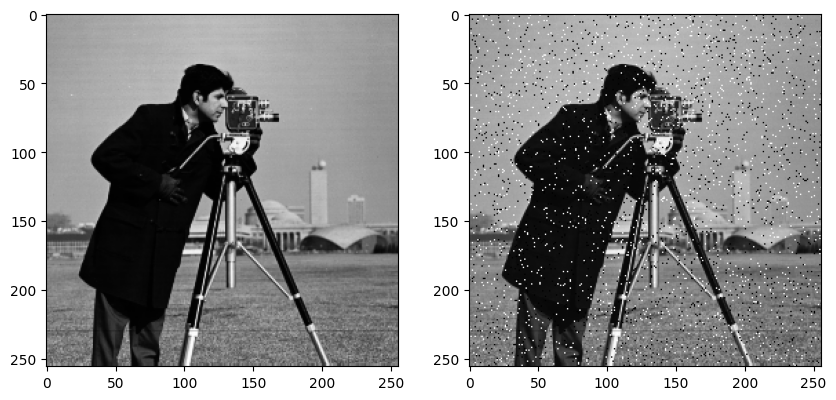

In [30]:
from src.utils import get_data_path
img = cv2.imread(get_data_path("cameraman.tif"), cv2.IMREAD_UNCHANGED)
print("图像尺寸:", img.shape, "数据类型:", img.dtype)

salt_and_pepper_noise_img=add_salt_and_pepper_noise(img, amount=0.05, salt_vs_pepper=0.5)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# 如果是灰度直接展示，如果是彩色需要转 BGR -> RGB
if len(img.shape) == 3:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axs[0].imshow(img_rgb)
else:
    axs[0].imshow(img, cmap="gray")
axs[1].imshow(salt_and_pepper_noise_img, cmap="gray")
plt.show()

In [31]:
# ---------------------------
# Filters
# ---------------------------
def gaussian_filter(img, ksize=5, sigma=1.0):
    ksize = max(3, int(ksize) | 1)
    return cv2.GaussianBlur(img, (ksize, ksize), sigmaX=sigma, sigmaY=sigma)


def mean_filter(img, ksize=5):
    ksize = max(3, int(ksize) | 1)
    return cv2.blur(img, (ksize, ksize))


def median_filter(img, ksize=5):
    ksize = max(3, int(ksize) | 1)
    if img.ndim == 2:
        return cv2.medianBlur(img, ksize)
    channels = cv2.split(img)
    filtered = [cv2.medianBlur(c, ksize) for c in channels]
    return cv2.merge(filtered)

In [32]:
# ---------------------------
# Metrics
# ---------------------------
def mse(img_a, img_b):
    a = img_a.astype(np.float32)
    b = img_b.astype(np.float32)
    return float(np.mean((a - b) ** 2))


def psnr(img_a, img_b, data_range=255.0):
    m = mse(img_a, img_b)
    if m == 0:
        return float("inf")
    return 10.0 * math.log10((data_range ** 2) / m)

MSE Gaussian filter: 851.370849609375
MSE Mean filter: 1191.947998046875
MSE Median filter: 1184.94140625


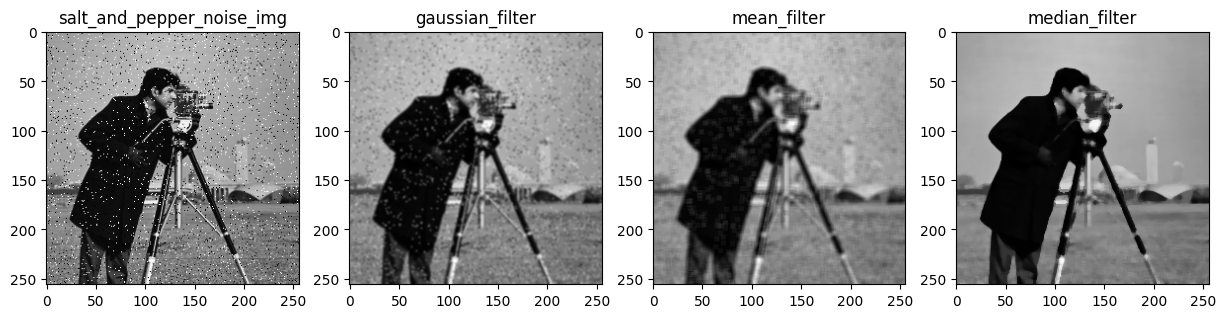

In [33]:
gaussian_filtered_img = gaussian_filter(salt_and_pepper_noise_img, ksize=5, sigma=1.0)
mean_filtered_img = mean_filter(salt_and_pepper_noise_img, ksize=5)
median_filtered_img = median_filter(salt_and_pepper_noise_img, ksize=5)

print("MSE Gaussian filter:", mse(salt_and_pepper_noise_img, gaussian_filtered_img))
print("MSE Mean filter:", mse(salt_and_pepper_noise_img, mean_filtered_img))
print("MSE Median filter:", mse(salt_and_pepper_noise_img, median_filtered_img))

fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs[0].imshow(salt_and_pepper_noise_img, cmap="gray")
axs[0].set_title("salt_and_pepper_noise_img")
axs[1].imshow(gaussian_filtered_img, cmap="gray")
axs[1].set_title("gaussian_filter")
axs[2].imshow(mean_filtered_img, cmap="gray")
axs[2].set_title("mean_filter")
axs[3].imshow(median_filtered_img, cmap="gray")
axs[3].set_title("median_filter")
plt.show()

In [34]:
# ---------------------------
# Sharpening
# ---------------------------
def sharpen_unsharp_mask(img, ksize=5, sigma=1.0, amount=1.0, threshold=0):
    blur = gaussian_filter(img, ksize=ksize, sigma=sigma)
    high = cv2.subtract(img, blur)
    sharp = cv2.addWeighted(img, 1.0, high, amount, 0)
    return sharp

MSE: 132.72299194335938
PSNR: 26.90134197542345


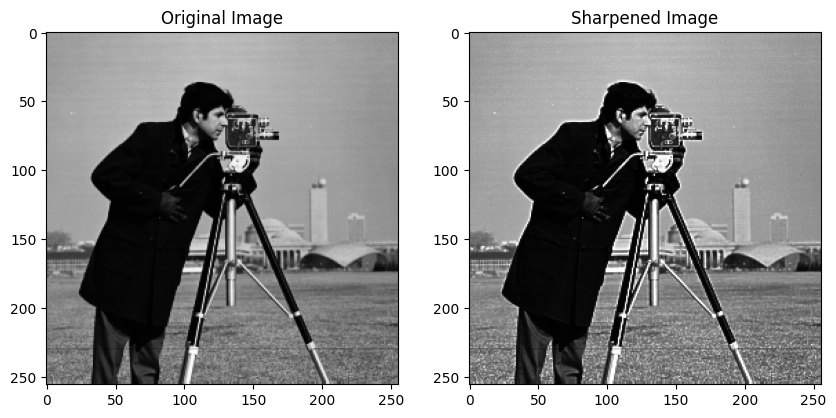

In [35]:
sharpened_img = sharpen_unsharp_mask(img, ksize=5, sigma=1.0, amount=1.5, threshold=0)

print("MSE:", mse(img, sharpened_img))
print("PSNR:", psnr(img, sharpened_img))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img, cmap="gray")
axs[0].set_title("Original Image")
axs[1].imshow(sharpened_img, cmap="gray")
axs[1].set_title("Sharpened Image")
plt.show()
